## Build A Basic Chatbot with Langgraph(GRAPH API)

In [18]:
from typing import Annotated


from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages 
# reducer


In [19]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [20]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = init_chat_model("gpt-4.1")

In [22]:
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-openai': '1.3.3'}}, output_version=None, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x114c03150>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1151b1a10>, root_client=<openai.OpenAI object at 0x114c11c50>, 

In [23]:
# Node functionality


def Chatbot(state:State):
    return {"messages" : [llm.invoke(state["messages"])]}

In [24]:
# build graph
graph_builder = StateGraph(State)

# Adding Nodes

graph_builder.add_node("llmchatbot",Chatbot)

# Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#compile the graph
graph= graph_builder.compile()



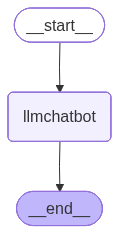

In [25]:
# Visualize the graph

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [26]:
response = graph.invoke({"messages": "Hi"})

In [27]:
response["messages"][-1].content

'Hello! How can I help you today? 😊'

In [28]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hi! I'm just a virtual assistant, but I'm ready to help. How can I assist you today?


Chatbot with tool

In [29]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [30]:
# custom tool function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args: 
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a*b

In [31]:
tools=[tool,multiply]

In [32]:
llm_with_tool=llm.bind_tools(tools)

In [33]:
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-openai': '1.3.3'}}, output_version=None, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x114c03150>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1151b1a10>, root_client=<openai.OpenAI 

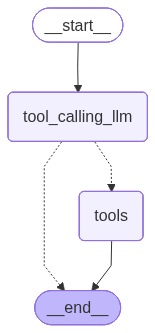

In [34]:
#state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder =StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:
response=graph.invoke({"messages":"What is the recent ai news"})


In [36]:

response['messages'][-1].content


'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/09/ai-trends-fable-5-sol-grok-china-us", "title": "Behind the Curtain: These 3 big AI trends are colliding at the same time - Axios", "score": 0.70580584, "published_date": "Thu, 09 Jul 2026 09:13:03 GMT", "content": "Elon Musk\'s SpaceXAI, fresh off its record-breaking IPO and $60 billion acquisition of Cursor, clawed its way back into the AI race Wednesday with the release of Grok 4.5 — a model triple the size of its predecessor. Musk says another model nearly twice as large is coming next month, doubling down on a bet that raw scale, not just smarter training, still wins.\\n Meanwhile, China is dominating the open-source race. GLM-5.2, built by Chinese startup Z.ai, is free to download and now performs in the same tier as America\'s priciest models. Z.ai founder Jie Tang predicted China will achieve a \\"Fable-class\\" model before Q1 of 2027. [.

In [37]:

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_scqpmZl93RUMGaX0Bu0kJkCl)
 Call ID: call_scqpmZl93RUMGaX0Bu0kJkCl
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/09/ai-trends-fable-5-sol-grok-china-us", "title": "Behind the Curtain: These 3 big AI trends are colliding at the same time - Axios", "score": 0.70580584, "published_date": "Thu, 09 Jul 2026 09:13:03 GMT", "content": "Elon Musk's SpaceXAI, fresh off its record-breaking IPO and $60 billion acquisition of Cursor, clawed its way back into the AI race Wednesday with the release of Grok 4.5 — a 

In [38]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (call_LIl4RcGl6ZYipPAj96DjUegA)
 Call ID: call_LIl4RcGl6ZYipPAj96DjUegA
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [39]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_ATpKQpg0GH12pbAKsp48vmPu)
 Call ID: call_ATpKQpg0GH12pbAKsp48vmPu
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
    time_range: week
  multiply (call_JPNZ9IKneSiwdDH1YyZ2S9pL)
 Call ID: call_JPNZ9IKneSiwdDH1YyZ2S9pL
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/09/ai-trends-fable-5-sol-grok-china-us", "title": "Behind the Curtain: These 3 big AI trends are colliding at the same time - Axios", "score": 0.70580584, "published_date": "Thu, 09 Jul 2026 09:13:03 GMT", "content": "Elon Musk's SpaceX

ReAct agent Architecture

In [42]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)


In [43]:

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [44]:
tools =[tool,multiply]

In [45]:
llm_with_tool= llm.bind_tools(tools)

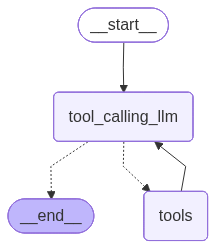

In [46]:
# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [47]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_e9Zsilk4eIRd2IbwNDx2Dfre)
 Call ID: call_e9Zsilk4eIRd2IbwNDx2Dfre
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
    time_range: week
  multiply (call_2STZ5mSyUPpMA4ceoWSPjZBd)
 Call ID: call_2STZ5mSyUPpMA4ceoWSPjZBd
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/09/ai-trends-fable-5-sol-grok-china-us", "title": "Behind the Curtain: These 3 big AI trends are colliding at the same time - Axios", "score": 0.70580584, "published_date": "Thu, 09 Jul 2026 09:13:03 GMT", "content": "Elon Musk's SpaceX

Adding Memory in Agentic Graph

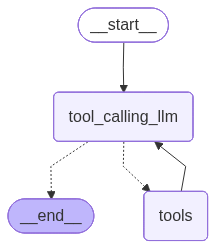

In [48]:
# state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


#node definition

def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

#Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools","tool_calling_llm")

# compile graph with memory

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


    

In [49]:
# to maintain context of specific conversation we need specific thread
config ={
    "configurable": {"thread_id": "1"}
}

response = graph.invoke({"messages":"Hi my name is Krish"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='aaa6d1d5-1ac8-459a-ba04-7668832ff376'),
  AIMessage(content='Hello Krish! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 1222, 'total_tokens': 1234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_b5121c360f', 'id': 'chatcmpl-DzsgVq5c7fcwimMc1nLbCzVX3LHdd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4943-78b1-70c1-924a-e3c2502ccb40-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1222, 'output_tokens': 12, 'total_tokens': 1234, 'input_token_details': {'audio': 0, 'cache_read': 

In [50]:

response['messages'][-1].content

'Hello Krish! How can I help you today?'

In [51]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)


Your name is Krish! How can I assist you further?


Streaming

In [55]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()


In [56]:

def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

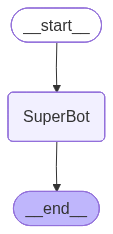

In [57]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [58]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='5690ccaa-4986-49fa-a185-b4e557fbcfd6'),
  AIMessage(content="Hi Krish! It's great to meet you. Cricket is such an exciting sport! Who’s your favorite cricketer or team? Do you like to play cricket, watch matches, or both?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 18, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_3a116720b9', 'id': 'chatcmpl-DzsijDMLQa8GXY5GVpXBWN5LUCX1Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4945-973e-7c00-9855-ad7b0e6fe33a-0', tool_calls=[], invalid_tool_call

In [59]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Krish! Nice to meet you. That’s awesome that you like cricket! Who’s your favorite cricket team or player? Do you play yourself, or do you mostly enjoy watching matches?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 18, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_68d5449d03', 'id': 'chatcmpl-DzsinvPGQHrBq99QViwNUGhWlG8DA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4945-a471-75d2-ac63-e85a90b147fc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 39, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_re

In [ ]:

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

In [60]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='899db51d-6c67-4d5f-a009-dfbd66d84d6f'), AIMessage(content='Hi Krish! Nice to meet you. That’s awesome that you like cricket! Who’s your favorite cricket team or player? Do you play yourself, or do you mostly enjoy watching matches?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 18, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_68d5449d03', 'id': 'chatcmpl-DzsinvPGQHrBq99QViwNUGhWlG8DA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4945-a471-75d2-ac63-e85a90b147fc-0', tool_calls=[], invalid

In [61]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Krish! 👋 It's great to meet you. Cricket is an amazing sport—do you play, or are you more of a fan who likes to watch matches? Who’s your favorite player or team?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 18, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_3a116720b9', 'id': 'chatcmpl-DzsjCvwUl2chum3BrSGdMvqFpTBxl', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4946-09fb-79c2-ada9-22aa191eae92-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 43, 'total_tokens': 61, 'input_token_details': {'audio': 0, 'cache_read': 0}

In [62]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6e254185-b321-45ac-9712-75459f1c5879'), AIMessage(content="Hi Krish! 👋 It's great to meet you. Cricket is an amazing sport—do you play, or are you more of a fan who likes to watch matches? Who’s your favorite player or team?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 18, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_3a116720b9', 'id': 'chatcmpl-DzsjCvwUl2chum3BrSGdMvqFpTBxl', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4946-09fb-79c2-ada9-22aa191eae92-0', tool_calls=[], invalid_tool_c

In [63]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)


{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4946-686e-7d53-8b13-5a35aaf07c4d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='98ddc8da-a159-476b-95cc-996014345099')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f4946-6870-7cd0-bfe3-73a21189cdb1', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:bede93b9-fea6-f1dd-4463-1a5f43cb91da'}, 'parent_ids': ['019f4946-686e-7d53-8b13-5a35aaf07c4d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':